# 10 — Analysis

**The concept:** `analyze`, `validate` and `explain` tell you what a solve *would* do, reading only
signatures, annotations and the dependency graph.

**No discipline is ever called.** That is the invariant the whole layer rests on: introspection
never requires execution. It also means these are free, so there is no reason not to run them.

In [1]:
from smartmdao import Pipeline, HybridSolver, analyze, validate, explain, PipelineAnalysis

pipeline = Pipeline(solver=HybridSolver())

@pipeline.step(outputs=["y1"])
def discipline_1(z: float, y2: float) -> float:
    return z**2 - 0.2 * y2

@pipeline.step(outputs=["y2"])
def discipline_2(y1: float) -> float:
    return abs(y1) ** 0.5

@pipeline.step(outputs=["objective"])
def objective(y1: float, y2: float) -> float:
    return y1 + y2

report = analyze(pipeline, inputs=["z"])
print(type(report).__name__)
print()
print("steps:            ", report.steps)
print("execution order:  ", report.execution_order)
print("external inputs:  ", report.external_inputs)
print("terminal outputs: ", report.terminal_outputs)
print("has cycles:       ", report.has_cycles)
print("recommended:      ", report.recommended_solver)
print("because:          ", report.reason)

PipelineAnalysis

steps:             ('discipline_1', 'discipline_2', 'objective')
execution order:   ('discipline_1', 'discipline_2', 'objective')
external inputs:   ('z',)
terminal outputs:  ('objective',)
has cycles:        True
recommended:       HybridSolver
because:           1 feedback loop(s) detected; DAGSolver would raise. HybridSolver runs acyclic steps once and iterates only the cyclic blocks.


## The analysis is **solver-aware**

This is not a detail. `IterativeSolver` sweeps in registration order and ignores the graph;
`HybridSolver` follows the graph and runs cyclic blocks alphabetically. **The same steps need
different variables seeded**, so an analysis that gave one answer for every pipeline would be
wrong.

In [2]:
from smartmdao import IterativeSolver, CycleAnalysis

hybrid_view = analyze(pipeline, inputs=["z"])

iterative = Pipeline(solver=IterativeSolver())
for fn, outs in ((discipline_1, ["y1"]), (discipline_2, ["y2"]), (objective, ["objective"])):
    iterative.add(fn, outputs=outs)
iterative_view = analyze(iterative, inputs=["z"])

print("HybridSolver    order:", hybrid_view.execution_order)
print("IterativeSolver order:", iterative_view.execution_order)
print()
for cycle in hybrid_view.cycles:
    print("cycle:", cycle.steps, "coupling on", cycle.feedback_variables)
    print("is a CycleAnalysis:", isinstance(cycle, CycleAnalysis))

HybridSolver    order: ('discipline_1', 'discipline_2', 'objective')
IterativeSolver order: ('discipline_1', 'discipline_2', 'objective')

cycle: ('discipline_1', 'discipline_2') coupling on ('y1', 'y2')
is a CycleAnalysis: True


## `validate()` — every structural problem at once

`validate()` never raises and never stops at the first problem. It returns a tuple of `Finding`,
worst first, so a whole pipeline can be fixed in one pass.

In [3]:
from smartmdao import Finding

print("a healthy pipeline:", validate(pipeline, inputs=["z"]))

a healthy pipeline: (Finding(code='initial-guess-required', severity='error', message="'discipline_1' consumes 'y2' before anything produces it, so the first sweep has nothing to read. Ordering here is decided by HybridSolver, so renaming a step or swapping solvers can change which variable this is. Pass y2=... to run().", step='discipline_1', variable='y2'),)


In [4]:
broken = Pipeline()

@broken.step(outputs=["mass"])
def structures(span: float) -> float:
    return span * 12.0

@broken.step(outputs=["mass"])                 # duplicate output
def alternative_mass(span: float) -> str:
    return "heavy"

@broken.step(outputs=["cost"])
def costing(mass: float, rate: float) -> float:   # `rate` comes from nowhere
    return mass * rate

for finding in validate(broken, inputs=["span"]):
    print(f"[{finding.severity.upper():7}] {finding.code}")
    print(f"          {finding.message}")
    print()

[ERROR  ] duplicate-output
          'mass' is declared as an output by both 'structures' and 'alternative_mass'. Only 'alternative_mass' will be wired up; the other result is computed and discarded.

[ERROR  ] type-mismatch
          'alternative_mass' declares mass -> str, but 'costing' expects mass: float.

[ERROR  ] missing-input
          'rate' is required by 'costing' but no step produces it and it was not listed as an input.



Each `Finding` carries a machine-readable `code`, a `severity`, and where it applies — so
tooling can act on it while a human reads the message.

In [5]:
finding = validate(broken, inputs=["span"])[0]
print("code:    ", finding.code)
print("severity:", finding.severity)
print("step:    ", finding.step)
print("variable:", finding.variable)
print()
print("rendered:", str(finding))
print("is a Finding:", isinstance(finding, Finding))

code:     duplicate-output
severity: error
step:     alternative_mass
variable: mass

rendered: ERROR: 'mass' is declared as an output by both 'structures' and 'alternative_mass'. Only 'alternative_mass' will be wired up; the other result is computed and discarded. [alternative_mass]
is a Finding: True


## Declare the inputs once

Every call above passed `inputs=`. Which names come from outside is a property of the
*pipeline*, not of each call — so say it once, on the pipeline. That matters most for a
**contract-first** pipeline: signatures written, bodies not yet, and no `run()` call anywhere
for a tool to read the inputs from.

The disciplines below only raise. Analysis still works, because it never calls them — the only
findings say they are stubs, which the next section covers.

In [6]:
contract = Pipeline(solver=HybridSolver(), inputs=["z", "y2"])

@contract.step(outputs=["y1"])
def discipline_1(z: float, y2: float) -> float:
    raise NotImplementedError("physics not written yet")

@contract.step(outputs=["y2"])
def discipline_2(z: float, y1: float) -> float:
    raise NotImplementedError("physics not written yet")

print("declared:    ", contract.inputs)
print("validate:    ", [finding.code for finding in validate(contract)])
print("seeds needed:", analyze(contract).initial_guesses_required)

declared:     ('z', 'y2')
validate:     ['stub-step', 'stub-step']
seeds needed: ()


An explicit list still **wins** — even an empty one — so "what if only `z` came in?" is
still a question you can ask:

In [7]:
for finding in validate(contract, inputs=["z"]):
    print(finding)

ERROR: 'discipline_1' consumes 'y2' before anything produces it, so the first sweep has nothing to read. Ordering here is decided by HybridSolver, so renaming a step or swapping solvers can change which variable this is. Pass y2=... to run(). [discipline_1]
INFO: 'discipline_1' only raises NotImplementedError - declared, not yet written. Analysis is unaffected; a run will stop here. [discipline_1]
INFO: 'discipline_2' only raises NotImplementedError - declared, not yet written. Analysis is unaffected; a run will stop here. [discipline_2]


### A name no step reads

Declaring inputs makes one more mistake visible. Misspell a name, and if the parameter it was
meant for has a **default**, nothing fails: the default is used and your value is thrown away.
`validate()` reports it as `unconsumed-input` — the only signal you get.

In [8]:
typo = Pipeline(inputs=["speed", "spn"])            # meant "span"

@typo.step(outputs=["lift"])
def lift(speed: float, span: float = 10.0) -> float:
    return speed * span

for finding in validate(typo):
    print(finding)

print()
print("run:", typo.run(speed=2.0, spn=30.0))
print("-> lift is 20, not 60: span kept its default and spn=30 went nowhere.")


run: {'speed': 2.0, 'spn': 30.0, 'lift': 20.0}
-> lift is 20, not 60: span kept its default and spn=30 went nowhere.


## How much of it is written? Stubs

A step whose body — docstring aside — is only `raise NotImplementedError` is a **stub**:
declared, not yet written. The check reads the source with `ast` and never calls the function.
A step whose source cannot be read (a builtin, a function made by `exec`) is *unknown*, and is
never counted as a stub — a wrong number would be worse than no number.

In [9]:
draft = Pipeline(inputs=["a"])

@draft.step(outputs=["b"])
def double(a: float) -> float:
    return a * 2

@draft.step(outputs=["c"])
def later(b: float) -> float:
    """Waiting on the supplier's rates."""
    raise NotImplementedError

print("stubs:", analyze(draft).stubs)
for finding in validate(draft):
    print(finding)
print()
print("Execution order" + explain(draft).split("Execution order")[1])

stubs: ('later',)
INFO: 'later' only raises NotImplementedError - declared, not yet written. Analysis is unaffected; a run will stop here. [later]

Execution order: double -> later

Not written yet (1 of 2 steps only raise NotImplementedError): later


A stub is **information**, not a problem: the pipeline is still valid. Running it is another
matter — and the error you get does not say "stub":

In [10]:
try:
    draft.run(a=1.0)
except Exception as error:
    print(type(error).__name__ + ":", error)

Error executing step 'later': 
Traceback (most recent call last):
  File "/home/wghami/Documents/GitHub/SmartMDAO/smartmdao/executor.py", line 46, in run_step
    result = step.fn(**params)
             ^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_45419/1667774504.py", line 10, in later
    raise NotImplementedError
NotImplementedError


Pipeline execution failed: Error executing step 'later': 


RuntimeError: Error executing step 'later': 


`double` ran and `later` stopped the run. The exception you catch is a `RuntimeError` naming the
step; the `NotImplementedError` underneath appears only in the log's traceback. That is why
`run_pipeline` over MCP lists the stubs in its result: the run still happens, so the steps
already written are exercised, and the reader learns *why* it stopped without reading a
traceback.

## The expensive mistake: a disconnected graph

This is the one worth knowing about. A pipeline whose graph falls into **separate pieces** validates
clean on every other check, converges, computes correct arithmetic — and produces an answer that
ignores half its inputs.

It was found in real use, where a generated wing model ignored three of its five inputs.

In [11]:
disconnected = Pipeline(solver=HybridSolver())

@disconnected.step(outputs=["lift"])
def compute_lift(span: float, chord: float, speed: float) -> float:
    return 0.5 * 1.225 * speed**2 * span * chord     # nothing ever reads `lift`

@disconnected.step(outputs=["mass"])
def mass_loop(mass: float) -> float:
    return 100.0 + 0.05 * mass                        # a loop closed on itself

for finding in validate(disconnected, inputs=["span", "chord", "speed", "mass"]):
    print(f"[{finding.code}] {finding.message}")

[disconnected-graph] The pipeline falls into 2 disconnected pieces, so nothing computed in one can affect another: ['compute_lift'] -> ['lift'] consumed by nothing; ['mass_loop']. This usually means a discipline was never wired in - its inputs will have no influence on the result, however well the rest converges.


Draw it and the problem stops being subtle — the diagram falls into two
pieces with nothing joining them:

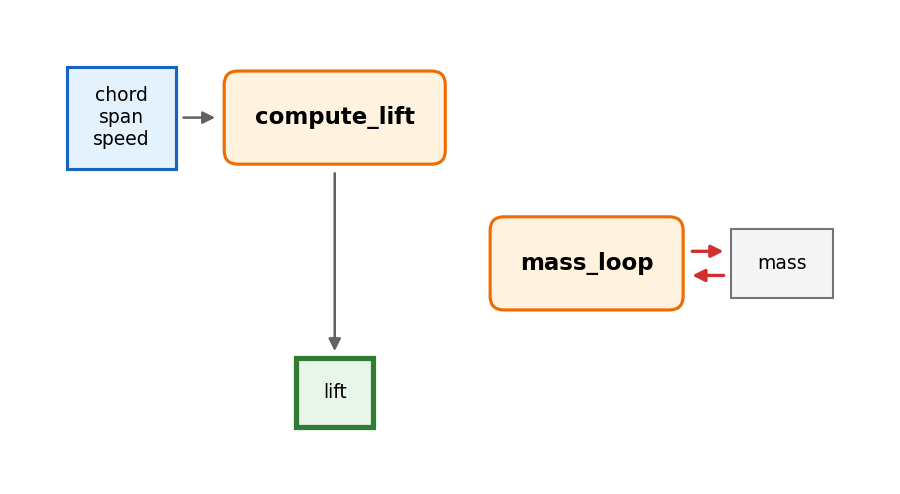

In [12]:
import matplotlib
matplotlib.use("Agg", force=True)

import pathlib, tempfile
from IPython.display import Image

_gallery = pathlib.Path(tempfile.mkdtemp())

def show(pipeline, inputs, name):
    """Render a pipeline to PNG and display it inline. See notebook 02."""
    path = _gallery / f"{name}.png"
    pipeline.visualize(inputs=inputs, output_path=str(path), view=False)
    return Image(filename=str(path))

show(disconnected, ["span", "chord", "speed", "mass"], "disconnected")

The arithmetic is right. The convergence is real. The answer does not depend on span, chord
or speed at all — and only the *disconnection* reveals it.

## `explain()` — the same thing, in prose

For a human, a review, or an agent that would rather read a paragraph than a data structure.

In [13]:
print(explain(pipeline, inputs=["z"]))

Pipeline with 3 step(s): discipline_1, discipline_2, objective.

Recommended solver: HybridSolver
  1 feedback loop(s) detected; DAGSolver would raise. HybridSolver runs acyclic steps once and iterates only the cyclic blocks.

External inputs: z
Final outputs:   objective

Feedback loops (1):
  1. discipline_1 -> discipline_2
     coupling on: y1, y2

Needs initial values for: y2 (for discipline_1)

Execution order: discipline_1 -> discipline_2 -> objective

Findings (1):
  ERROR: 'discipline_1' consumes 'y2' before anything produces it, so the first sweep has nothing to read. Ordering here is decided by HybridSolver, so renaming a step or swapping solvers can change which variable this is. Pass y2=... to run(). [discipline_1]


## Analysis is the cheapest rung on the cost ladder

| Rung | Cost |
|---|---|
| `analyze` / `validate` / `explain` | **free** — nothing executes |
| one sweep | one call per discipline |
| budgeted run | capped sweeps and a wall clock |
| full run | whatever it takes |
| `optimize` | a full run, 10²–10³ times |

Everything on this page sits on the top row. Run it always; it costs nothing and it catches the
class of mistake that otherwise reaches a design review.

---

**Next:** [2 — Visualization](02-visualization.ipynb).